In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
from torch.distributions import Categorical


In [3]:
GRID_SIZE = 5
ACTION = [
    (-1,0), (0,1),
    (1,0), (0,-1),
    (0,0)
    ]
ACTION_SYMBOLS = [
    '↑', '→',
    '↓', '←',
    'O'
    ]
GOAL_STATE = (3, 2)
OBSTACLE = [
    (1,1), (1,2),
    (2,2),
    (3,1), (3,3),
    (4,1)
]



GAMMA = 0.9
ALPHA_W = 0.001  # Critic学习率要比Actor学习率大一些
ALPHA_THETA = 0.0001
num_episodes = 2000
num_steps = 1000
state_dim = 25
action_dim = len(ACTION)
is_linear = False
obstacle_through = False

In [4]:
import numpy as np

"""
环境 (纯坐标端到端版本)
"""
class GridEnv:
    def __init__(self, GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, obstacle_through=False):
        self.GRID_SIZE = GRID_SIZE
        self.GOAL_STATE = GOAL_STATE
        self.OBSTACLE = OBSTACLE
        self.ACTION = ACTION
        self.obstacle_through = obstacle_through

        # 状态维度直接变成 2 (代表 r 和 c 两个连续数值)
        self.state_dim = 2 
        self.current_state = None
    
    def reset(self):
        """
        episode 重置：随机生成一个合法的起点，并直接返回其 2D 坐标
        """
        while True:
            r = np.random.randint(self.GRID_SIZE)
            c = np.random.randint(self.GRID_SIZE)
            state = (r, c)
            if state == self.GOAL_STATE:
                continue
            if not self.obstacle_through and state in self.OBSTACLE:
                continue
            break

        self.current_state = state
        
        # 直接返回转换为浮点型数组的坐标 [r, c]
        return np.array(self.current_state, dtype=np.float32)
    
    def step(self, action_idx):
        """
        执行动作：返回 next_state(坐标形式), reward, done(是否结束)
        """
        r, c = self.current_state
        dr, dc = self.ACTION[action_idx]
        next_r, next_c = r + dr, c + dc

        done = False

        # 边界检查
        if next_r < 0 or next_r >= self.GRID_SIZE or next_c < 0 or next_c >= self.GRID_SIZE:
            reward = -1.0
            next_state = self.current_state
        
        else:
            next_state = (next_r, next_c)
            if self.obstacle_through and next_state in self.OBSTACLE:
                reward = -1.0

            elif not self.obstacle_through and next_state in self.OBSTACLE:
                reward = -1.0
                next_state = self.current_state
            
            elif next_state == self.GOAL_STATE:
                reward = 1.0
                done = True  # 到达终点，episode 结束
            
            else:
                reward = -0.1 # 每一步的惩罚，鼓励智能体尽快找到目标
        
        self.current_state = next_state

        # 直接返回转换为浮点型数组的坐标 [r, c]
        return np.array(self.current_state, dtype=np.float32), reward, done

In [5]:
"""
QAC A2C Actor-Critic网络 训练完成策略提取函数
"""
def extract_v_and_policy_from_qac(trained_model, env, grid_size, device):
    V_matrix = np.zeros((grid_size, grid_size), dtype=np.float32)
    policy_matrix = np.zeros((grid_size, grid_size), dtype=int)
    
    trained_model.eval() # 锁定网络
    
    for r in range(grid_size):
        for c in range(grid_size):
            state = (r, c)
            state_tensor = torch.FloatTensor(state).to(device)
            
            with torch.no_grad():
                # 1. 提取 Actor 的策略 (取出概率分布)
                action_probs = trained_model.get_action_probs(state_tensor)
                
                # 找出概率最大的动作作为策略箭头
                best_action = torch.argmax(action_probs).item()
                policy_matrix[r, c] = best_action
                
                # 2. 提取 Critic 的 Q 值
                q_values = trained_model.get_q_values(state_tensor)
                
                # 🌟 核心魔法：V(s) = sum( pi(a|s) * Q(s,a) )
                v_value = torch.sum(action_probs * q_values).item()
                V_matrix[r, c] = v_value
                
    return V_matrix, policy_matrix

def extract_v_and_policy_from_a2c(trained_model, env, grid_size, device):
    V_matrix = np.zeros((grid_size, grid_size), dtype=np.float32)
    policy_matrix = np.zeros((grid_size, grid_size), dtype=int)
    
    trained_model.eval() 
    
    for r in range(grid_size):
        for c in range(grid_size):
            state = (r, c)
            
            state_vector = env._get_state_vector(state)
            state_tensor = torch.FloatTensor(state_vector).to(device)
            
            with torch.no_grad():
                action_probs = trained_model.get_action_probs(state_tensor).cpu().numpy()
                best_action = np.argmax(action_probs)
                policy_matrix[r, c] = best_action
                
                v_value = trained_model.get_v_state_value(state_tensor).cpu().item()
                V_matrix[r, c] = v_value
                
    return V_matrix, policy_matrix

"""
可视化 (Heatmap & Policy Arrows)
"""
def visualize_grid(V, policy, ALPHA_W, ALPHA_THETA, OBSTACLE, obstacle_through=False):
    plt.figure(figsize=(8, 6))
    
    V_plot = np.copy(V)
    # 只有在不允许穿透时，才把障碍物设为 NaN 挖空（显示为背景色）
    # 如果允许穿透，我们要保留它惨烈的负分，让热力图显示出来
    if not obstacle_through:
        for (r, c) in OBSTACLE:
            V_plot[r, c] = np.nan
        
    ax = sns.heatmap(V_plot, annot=True, fmt=".2f", cmap="YlGnBu", 
                     linewidths=.5, cbar_kws={'label': 'State Value $V(s)$'})
    
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            state = (i, j)
            
            if not obstacle_through and state in OBSTACLE:
                # 不可穿透的墙，画上灰色大方块
                ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='gray', fontsize=20)
            
            elif state == GOAL_STATE:
                # 终点
                symbol = ACTION_SYMBOLS[policy[i, j]]
                ax.text(j + 0.5, i + 0.8, f"GOAL({symbol})", ha='center', va='center', color='red', weight='bold')
            
            else:
                symbol = ACTION_SYMBOLS[policy[i, j]]
                
                # 如果允许穿透，给障碍物格子加上特殊的色和紫色箭头
                if obstacle_through and state in OBSTACLE:
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='purple', fontsize=18, weight='bold')
                    ax.text(j + 0.5, i + 0.5, '██', ha='center', va='center', color='red', alpha=0.3, fontsize=20)
                else:
                    # 正常平地
                    ax.text(j + 0.5, i + 0.8, symbol, ha='center', va='center', color='black', fontsize=16, weight='bold')
                
    plt.title(rf"Control ($\gamma$={GAMMA}, $\alpha_w$={ALPHA_W} $\alpha_\theta$={ALPHA_THETA}) | Obstacle Through: {obstacle_through}")
    plt.show()


def plot_learning_curve(learning_curve, window_size=100):
    """
    繪製學習曲線，包含原始回報和滑動平均回報
    """
    plt.figure(figsize=(10, 6))
    
    # 1. 繪製原始數據 (淺藍色，透明度低，用於觀察波動範圍)
    plt.plot(learning_curve, color='blue', alpha=0.2, label='Raw Total Reward')
    
    # 2. 計算並繪製滑動平均線 (紅色，較粗，用於觀察收斂趨勢)
    # 只有當 episode 數量大於窗口大小時才計算
    if len(learning_curve) >= window_size:
        # 使用 np.convolve 快速計算滑動平均
        moving_avg = np.convolve(learning_curve, np.ones(window_size)/window_size, mode='valid')
        # x 軸需要對齊，因為 valid 模式會砍掉前面的 window_size - 1 個點
        x_axis = np.arange(window_size - 1, len(learning_curve))
        plt.plot(x_axis, moving_avg, color='red', linewidth=2.5, label=f'Moving Average')
        
    plt.title('Learning Curve', fontsize=16)
    plt.xlabel('Episode', fontsize=14)
    plt.ylabel('Total Reward per Episode', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()



In [6]:
"""
人工特征提取器
"""
def get_poly_features(state):
    r, c = state
    # 手工构造 phi(s) = [1, r, c, r^2, c^2, rc] 二阶多项式特征
    return torch.FloatTensor([1, r, c, r**2, c**2, r*c])

"""
线性函数逼近器下的 Actor-Critic 算法  (w^T * phi(s)表达)
"""
class LinearAcotrCritic(nn.Module):
    def __init__(self, feature_dim = 6, action_dim = 5):
        super().__init__()

        # Actor 经过线性映射后直接 softmax 输出动作概率, 参数为 theta_t 
        self.actor_linear = nn.Linear(feature_dim, action_dim, bias=False)
        # Critic 经过线性映射后直接输出状态值, 参数为 w_t
        self.critic_linear = nn.Linear(feature_dim, action_dim, bias=False)

    def get_action_probs(self, phi_s):
        # pi(a|s, theta) = softmax(theta^T * phi(s))
        return torch.softmax(self.actor_linear(phi_s), dim=-1)
    
    def get_q_values(self, phi_s):
        # q(s, a, w) = w^T * phi(s)
        return self.critic_linear(phi_s)

"""
端到端深度提取器 
"""
class DeepActorCritic(nn.Module):
    def __init__(self, state_dim = 2, action_dim = 5):
        super().__init__()

        # 共享特征提取层 隐式提取 phi(s)
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        # Actor 输出头 参数为 theta_t
        self.actor_head = nn.Linear(128, action_dim)
        # Critic 输出头 参数为 w_t
        self.critic_head = nn.Linear(128, action_dim)
    
    def get_action_probs(self, raw_s):
        # 端到端直接输入原始状态 s
        phi_s = self.shared_net(raw_s)
        return torch.softmax(self.actor_head(phi_s), dim=-1)
    
    def get_q_values(self, raw_s):
        # 端到端直接输入原始状态 s
        phi_s = self.shared_net(raw_s)
        return self.critic_head(phi_s)
    

In [7]:
"""
QAC算法 训练
Critic  Value update 使用 TD target 进行 MSE 反向传播更新参数 w_t 变为 w_{t+1}
TD_target : r_{t+1} + GAMMA * q(s_{t+1}, a_{t+1}, w_t)  (非终止状态)
 - formula: w_{t+1} = w_t + ALPHA_W * (TD_target - q(s_t, a_t, w_t)) * grad_w q(s_t, a_t, w_t)
Actor  Policy update 使用更新后的 Critic 输出 q(s_t, a_t, w_{t+1}) 进行策略梯度更新参数 theta_t 变为 theta_{t+1}
 - formula: theta_{t+1} = theta_t + ALPHA_THETA * grad_theta log pi(a_t|s_t, theta_t) * q(s_t, a_t, w_{t+1})
"""
def train_QAC(env, model, device, num_episodes, num_steps, GAMMA, ALPHA_W, ALPHA_THETA, is_linear=False):

    if is_linear:
        # 根据不同模式选择不同的优化器
        optimizer_C = optim.Adam(model.critic_linear.parameters(), lr=ALPHA_W)
        optimizer_A = optim.Adam(model.actor_linear.parameters(), lr=ALPHA_THETA)
    else:
        # Deep 模式需要加入额外的shared_net优化器
        optimizer_C = optim.Adam(list(model.critic_head.parameters()) + list(model.shared_net.parameters()), lr=ALPHA_W)
        optimizer_A = optim.Adam(list(model.actor_head.parameters()) + list(model.shared_net.parameters()), lr=ALPHA_THETA)

    return_history = []

    for ep in range(num_episodes):
        state = env.reset()

        # 预处理状态输入
        s_input = get_poly_features(state) if is_linear else torch.FloatTensor(state)
        s_input = s_input.to(device) 

        # Generate a_t following pi(a|s, theta_t)
        probs = model.get_action_probs(s_input)
        m = Categorical(probs)
        action = m.sample()

        episode_reward = 0 

        for t in range(num_steps):
            # 执行动作 a_t, 观察 r_{t+1}, s_{t+1}
            next_state, reward, done = env.step(action.item())
            episode_reward += reward

            next_s_input = get_poly_features(next_state) if is_linear else torch.FloatTensor(next_state)
            next_s_input = next_s_input.to(device)

            # generate a_{t+1} following pi(a|s_{t+1}, theta_t)
            next_probs  = model.get_action_probs(next_s_input)
            next_m = Categorical(next_probs)
            next_action = next_m.sample()

            # 核心  Critic (Value update)
            q_current = model.get_q_values(s_input)[action]

            with torch.no_grad(): # 不计算梯度的情况下, 计算 TD target
                if done:
                    TD_target = torch.tensor(reward, dtype=torch.float32, device=device) # 终止状态没有下一个状态的值
                else:
                    next_q_value = model.get_q_values(next_s_input)[next_action]
                    TD_target = reward + GAMMA * next_q_value
            
            # MSE 反向传播更新 Critic 参数 w_t
            loss_fn_C = nn.MSELoss()
            loss_C = loss_fn_C(q_current, TD_target) # 等价于 (TD_target - q_current) ** 2, 不带 0.5 常数项，相当于学习率翻倍
            # loss_C = 0.5 * (TD_target - q_current) ** 2 # 也可以手动计算梯度并更新参数
            
            optimizer_C.zero_grad()
            loss_C.backward()
            optimizer_C.step() # 更新 Critic 参数 w_t 变为 w_{t+1}


            # Actor (Policy update)
            with torch.no_grad(): # 不计算梯度的情况下, 计算更新后的 q(s_t, a_t, w_{t+1})
                new_w_q_value = model.get_q_values(s_input)[action] # 使用更新后的 Critic 计算新的 q(s_t, a_t, w_{t+1})
            
            # 重新计算对于 s_t 的动作概率分布 pi(a|s_t, theta_t) 和 log prob
            probs_new = model.get_action_probs(s_input)
            m_new = Categorical(probs_new)
            log_prob = m_new.log_prob(action)

            # 策略梯度更新 Actor 参数 theta_t 变为 theta_{t+1}
            # 梯度上升, 因此 loss 取负号
            loss_A = -log_prob * new_w_q_value

            optimizer_A.zero_grad()
            loss_A.backward()
            optimizer_A.step() # 此时，网络里变成了 theta_{t+1}

            if done:
                break

            # 更新状态
            state = next_state
            s_input = next_s_input
            action = next_action

        return_history.append(episode_reward)
        # print(f"Episode {ep+1}/{num_episodes}, Return: {episode_reward:.2f}")
        if(ep+1) % 100 == 0:
            print(f"Episode {ep+1}/{num_episodes}, Return: {episode_reward:.2f}")

    return model, return_history


In [52]:
env_QAC = GridEnv(GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, obstacle_through=obstacle_through)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")

当前使用的计算设备: cpu


In [53]:
model = DeepActorCritic(state_dim=2, action_dim=action_dim).to(device)

In [55]:
trained_model_QAC, return_history_QAC = train_QAC(
    env_QAC, model, device, num_episodes=num_episodes, num_steps=num_steps, 
    GAMMA=0.9, ALPHA_W=ALPHA_W, ALPHA_THETA=ALPHA_THETA, 
    is_linear=is_linear
    
)
torch.save(trained_model_QAC.state_dict(), "qac_maze_weights.pth")
print("🎉 模型权重已成功保存为 qac_maze_weights.pth!")

Episode 100/2000, Return: -14.41
Episode 200/2000, Return: -13.24
Episode 300/2000, Return: -20.43
Episode 400/2000, Return: -11.53
Episode 500/2000, Return: -11.08
Episode 600/2000, Return: -12.70
Episode 700/2000, Return: -11.44
Episode 800/2000, Return: -10.18
Episode 900/2000, Return: -11.08
Episode 1000/2000, Return: -10.00
Episode 1100/2000, Return: -0.60
Episode 1200/2000, Return: -12.07
Episode 1300/2000, Return: -10.18
Episode 1400/2000, Return: -10.00
Episode 1500/2000, Return: -10.00
Episode 1600/2000, Return: -10.00
Episode 1700/2000, Return: -12.34
Episode 1800/2000, Return: -10.09
Episode 1900/2000, Return: -10.00
Episode 2000/2000, Return: -10.18
🎉 模型权重已成功保存为 qac_maze_weights.pth!


In [8]:
"""
A2C 端对端深度网络  on-policy
"""

class DeepA2C(nn.Module):
    def __init__(self, grid_size = 5, state_dim = 2, action_dim = 5, seperate_extractor=False):
        super().__init__()
        self.grid_size = grid_size
        self.seperate_extractor = seperate_extractor

        self.embedding = nn.Embedding(grid_size*grid_size, 64)

        # 共享特征提取层 隐式提取 phi(s)
        self.shared_net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )
        # 尝试 actor和critic分开提取特征
        self.actor_net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )
        self.critic_net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Actor 输出头 参数为 theta_t 输出 5 个动作的概率
        self.actor_head = nn.Linear(128, action_dim)
        # Critic 输出头 参数为 w_t 只输出一个状态值 V(s)，而不是每个动作的 Q(s,a)
        self.critic_head = nn.Linear(128, 1)

    # 返回0-24的状态索引
    def _get_state_idx(self, raw_s):
        # 处理单个输入 [r,c] 或 batch 输入 [[r,c], [r,c], ...]
        return raw_s.argmax(dim=-1).long()
        
    def get_action_probs(self, raw_s):
        if self.seperate_extractor:
            idx = self._get_state_idx(raw_s)
            emb = self.embedding(idx)

            return torch.softmax(self.actor_net(emb), dim=-1)
        else:
            phi_s = self.shared_net(raw_s)
            return torch.softmax(self.actor_head(phi_s), dim=-1)
    
    def get_v_state_value(self, raw_s):
        if self.seperate_extractor:
            idx = self._get_state_idx(raw_s)
            emb = self.embedding(idx)

            return self.critic_net(emb) # 直接返回网络输出的纯数值 V(s)
        else:
            phi_s = self.shared_net(raw_s)
            return self.critic_head(phi_s)
    

In [12]:
"""
A2C算法 训练
Value update 变成 TD error (Advantage function) 更新 Critic 参数 w_t
advantage function (TD error): delta = r_{t+1} + gamma * v(s_{t+1}, w_t) - v(s_t, w_t)
 - formula: w_{t+1} = w_t + ALPHA_W * delta * grad_w v(s_t, w_t)
Policy update  策略梯度更新 Actor 参数 theta_t
 - formula: theta_{t+1} = theta_t + ALPHA_THETA * delta * grad_theta log pi(a_t|s_t, theta_t)
"""

def train_A2C(env, model, device, num_episodes, num_steps, GAMMA, ALPHA_W, ALPHA_THETA, is_linear=False):

    # 根据不同模式选择不同的优化器
    if is_linear:
        # 根据不同模式选择不同的优化器
        optimizer_C = optim.Adam(model.critic_linear.parameters(), lr=ALPHA_W)
        optimizer_A = optim.Adam(model.actor_linear.parameters(), lr=ALPHA_THETA)
    else:
        # Deep 模式需要加入额外的shared_net优化器
        if model.seperate_extractor:
            optimizer_C = optim.Adam(list(model.critic_net.parameters()) + list(model.embedding.parameters()) , lr=ALPHA_W)
            optimizer_A = optim.Adam(list(model.actor_net.parameters()) + list(model.embedding.parameters()), lr=ALPHA_THETA)
        else:
            optimizer_C = optim.Adam(list(model.critic_head.parameters()) + list(model.shared_net.parameters()), lr=ALPHA_W)
            optimizer_A = optim.Adam(list(model.actor_head.parameters()) + list(model.shared_net.parameters()), lr=ALPHA_THETA)

    return_history = []

    for ep in range(num_episodes):
        state = env.reset()

        # 预处理状态输入
        s_input = get_poly_features(state) if is_linear else torch.FloatTensor(state)
        s_input = s_input.to(device)

        episode_reward = 0

        for t in range(num_steps):
            # Generate a_t following pi(a|s_t, theta_t)
            probs = model.get_action_probs(s_input)
            m = Categorical(probs)
            action = m.sample()

            # 执行动作 a_t, 观察 r_{t+1}, s_{t+1}
            next_state, reward, done = env.step(action.item())
            episode_reward += reward

            next_s_input = get_poly_features(next_state) if is_linear else torch.FloatTensor(next_state)
            next_s_input = next_s_input.to(device)

            # 计算 TD_error (Advantage function)
            # \Delta = r_{t+1} + gamme*v(s_{t+1}, w_t) - v(s_t, w_t)
            v_current = model.get_v_state_value(s_input)[0] # 标量 v(s_t, w_t)

            with torch.no_grad():
                if done:
                    TD_target = torch.tensor(reward, dtype=torch.float32, device=device) # 终止状态没有下一个状态的值
                else:
                    v_next = model.get_v_state_value(next_s_input)[0] # 标量 v(s_{t+1}, w_t)
                    TD_target = reward + GAMMA * v_next
                
            TD_error = TD_target - v_current 

            # Critic (Value Update) 更新 w_t 变为 w_{t+1}
            loss_C = 0.5*(TD_error**2) # MSE Loss

            optimizer_C.zero_grad()
            loss_C.backward()
            optimizer_C.step()

            # Actor (Policy Update) 更新 theta_t 变为 theta_{t+1}
            # 重新拿一下当前的分布 构建 log_prob
            probs_new = model.get_action_probs(s_input)
            m_new = Categorical(probs_new)
            log_prob = m_new.log_prob(action)

            # delta 必须 detach()，否则 Actor 的更新会反过来影响 Critic 的 TD_error 计算，导致训练不稳定
            loss_A = -log_prob * TD_error.detach() # 策略梯度上升

            optimizer_A.zero_grad()
            loss_A.backward()
            optimizer_A.step()

            if done:
                break

            # 更新状态
            state = next_state
            s_input = next_s_input
        print(f"Episode {ep+1}/{num_episodes}, Step {t+1}/{num_steps}, Reward: {reward:.2f}, TD_error: {TD_error.item():.4f}")
        return_history.append(episode_reward)
        if(ep+1) % 100 == 0:
            print(f"Episode {ep+1}/{num_episodes}, Return: {episode_reward:.2f}")
    return model, return_history



In [13]:
env_A2C = GridEnv(GRID_SIZE, GOAL_STATE, OBSTACLE, ACTION, obstacle_through=obstacle_through)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"当前使用的计算设备: {device}")
model_A2C = DeepA2C(grid_size=GRID_SIZE, state_dim=2, action_dim=action_dim, seperate_extractor=True).to(device)


当前使用的计算设备: cpu


In [14]:
trained_model_A2C, return_history_A2C = train_A2C(
    env_A2C, model_A2C, device, num_episodes=num_episodes, num_steps=num_steps, 
    GAMMA=0.9, ALPHA_W=0.01, ALPHA_THETA=0.0003, 
    is_linear=is_linear
)
torch.save(trained_model_A2C.state_dict(), "a2c_maze_weights.pth")
print("🎉 模型权重已成功保存为 a2c_maze_weights.pth!")

Episode 1/2000, Step 172/1000, Reward: 1.00, TD_error: 10.7029
Episode 2/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 3/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 4/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 5/2000, Step 3/1000, Reward: 1.00, TD_error: 1.6241
Episode 6/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 7/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 8/2000, Step 1000/1000, Reward: -0.10, TD_error: -0.0000
Episode 9/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 10/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 11/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 12/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 13/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 14/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 15/2000, Step 1000/1000, Reward: -0.10, TD_error: 0.0000
Episode 16/2000, Step 1000/1000, Rewar

In [15]:
model_trained_QAC = DeepActorCritic(state_dim=2, action_dim=action_dim).to(device)
weights_dict = torch.load("qac_maze_weights.pth", map_location=device)
model_trained_QAC.load_state_dict(weights_dict)
policy_qac, conf_qac = extract_v_and_policy_from_qac(model_trained_QAC, env_QAC, GRID_SIZE, device)

C:\Users\Dieu\AppData\Local\Temp\ipykernel_11492\3471958747.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_dict = torch.load("qac_maze_weights.pth", map_locatio

NameError: name 'env_QAC' is not defined

In [16]:
visualize_grid(policy_qac, conf_qac, ALPHA_W, ALPHA_THETA, OBSTACLE, obstacle_through=obstacle_through)
plot_learning_curve(return_history_QAC, window_size=100)

NameError: name 'policy_qac' is not defined

In [17]:
model_trained_A2C = DeepA2C(grid_size=GRID_SIZE, state_dim=2, action_dim=action_dim, seperate_extractor=True).to(device)
weights_dict = torch.load("a2c_maze_weights.pth", map_location=device)
model_trained_A2C.load_state_dict(weights_dict)
v_A2C, policy_a2c = extract_v_and_policy_from_a2c(model_trained_A2C, env_A2C, GRID_SIZE, device)

C:\Users\Dieu\AppData\Local\Temp\ipykernel_11492\882749227.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights_dict = torch.load("a2c_maze_weights.pth", map_location

AttributeError: 'GridEnv' object has no attribute '_get_state_vector'

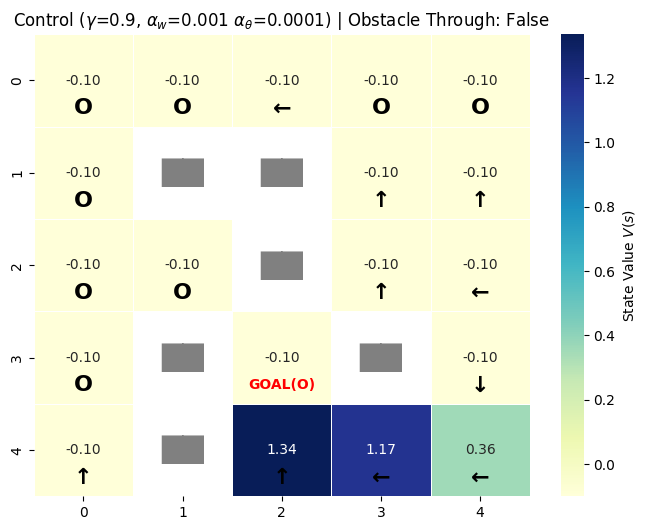

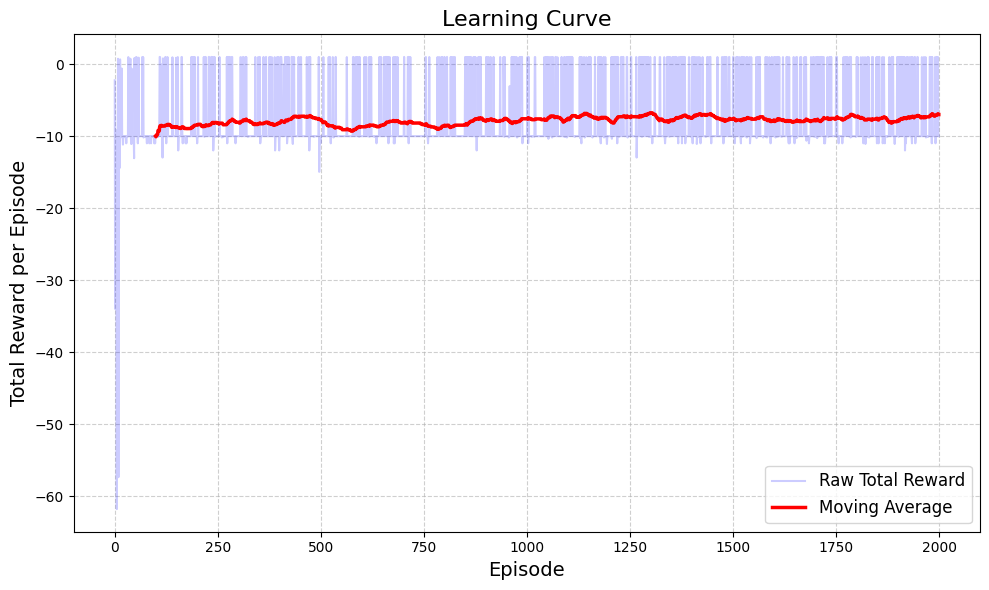

In [90]:
visualize_grid(v_A2C, policy_a2c, ALPHA_W, ALPHA_THETA, OBSTACLE, obstacle_through=obstacle_through)
plot_learning_curve(return_history_A2C, window_size=100)